# Build Your First Neural Network - Banknote Authentication Dataset

**Problem Statement:** Build a small ANN in Keras with the exact architecture
`Dense(16, activation="relu") -> Dense(8, activation="relu") -> Dense(1, activation="sigmoid")`.
Compile with the Adam optimizer and `binary_crossentropy` loss, split the data into train/test,
train for about 30 epochs, and report test accuracy. Plot the training vs. validation loss curve.

## 1. Importing Required Libraries

In [1]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # suppress TensorFlow info/warning logs

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import warnings
warnings.filterwarnings("ignore")

tf.random.set_seed(42)
np.random.seed(42)

I0000 00:00:1784992702.470103     947 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


I0000 00:00:1784992704.191721     947 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


## 2. Loading the Dataset

In [2]:
df = pd.read_csv("BankNote_Authentication.csv")

In [3]:
df.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [4]:
df.shape

(1372, 5)

* The dataset has 1,372 banknote samples described by 4 numeric features extracted from wavelet-transformed images, with `class` (0 = genuine, 1 = forged) as the target.

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1372 entries, 0 to 1371
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   variance  1372 non-null   float64
 1   skewness  1372 non-null   float64
 2   curtosis  1372 non-null   float64
 3   entropy   1372 non-null   float64
 4   class     1372 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 53.7 KB


* All 5 columns are numeric, so no categorical encoding is required.

In [6]:
df.isnull().sum()

variance    0
skewness    0
curtosis    0
entropy     0
class       0
dtype: int64

* There are zero missing values in any column.

In [7]:
df.duplicated().sum()

np.int64(24)

* There are 24 duplicate rows, which we remove so the same banknote measurement isn't counted twice across train/test.

In [8]:
df = df.drop_duplicates().reset_index(drop=True)
df.shape

(1348, 5)

In [9]:
df['class'].value_counts()

class
0    738
1    610
Name: count, dtype: int64

* The classes are reasonably balanced (roughly 56% genuine vs 44% forged), so accuracy is a meaningful metric here without further rebalancing.

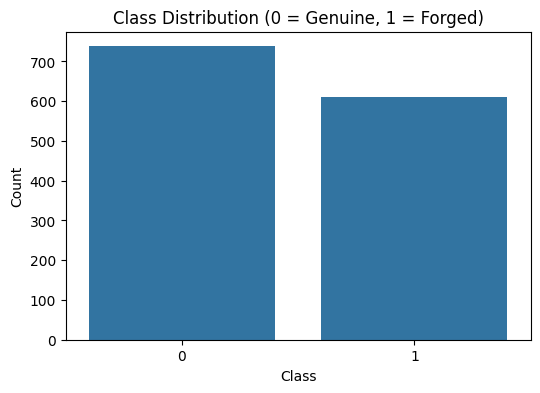

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='class', data=df)
plt.title("Class Distribution (0 = Genuine, 1 = Forged)")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

* The bar chart confirms the two classes are close enough in size that class imbalance shouldn't distort the test accuracy we report later.

## 3. Defining Features (X) and Target (y)

In [11]:
X = df.drop("class", axis=1)
y = df["class"]
X.shape, y.shape

((1348, 4), (1348,))

## 4. Train / Test Split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
X_train.shape, X_test.shape

((1078, 4), (270, 4))

* The data is split 80/20 with stratification on `class`, giving 1,078 training rows and 270 test rows while preserving the class ratio.

## 5. Feature Scaling

In [13]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* Scaling is fit only on the training data and applied to the test data; neural networks train faster and more stably when input features are on a similar scale.

## 6. Building the ANN (Exact Required Architecture)

In [14]:
model = keras.Sequential([
    keras.Input(shape=(X_train_scaled.shape[1],)),
    layers.Dense(16, activation="relu"),
    layers.Dense(8, activation="relu"),
    layers.Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 225 (900.00 B)

 Trainable params: 225 (900.00 B)

 Non-trainable params: 0 (0.00 B)

* The network has an input of 4 features, a hidden layer of 16 ReLU units, a second hidden layer of 8 ReLU units, and a single sigmoid output unit for binary classification, exactly as specified.

## 7. Compiling the Model

In [15]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])

* Adam is used as the optimizer and `binary_crossentropy` as the loss function, which is the standard pairing for a sigmoid-output binary classifier.

## 8. Training the Model (30 Epochs)

In [16]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=16,
    verbose=1
)

Epoch 1/30


 1/54 ━━━━━━━━━━━━━━━━━━━━ 52s 987ms/step - accuracy: 0.6875 - loss: 0.6887

39/54 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.5657 - loss: 0.6853   

54/54 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5568 - loss: 0.6689 - val_accuracy: 0.5417 - val_loss: 0.6185


Epoch 2/30


...

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 1.0000 - loss: 0.0074 - val_accuracy: 1.0000 - val_loss: 0.0060


Epoch 30/30


 1/54 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step - accuracy: 1.0000 - loss: 0.0011

32/54 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 1.0000 - loss: 0.0054  

54/54 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 1.0000 - loss: 0.0069 - val_accuracy: 1.0000 - val_loss: 0.0056


* The model trains for 30 epochs with 20% of the training data held out as a validation set each epoch, so we can watch training loss and validation loss diverge (or not) in real time.

## 9. Evaluating on the Test Set

In [17]:
test_loss, test_accuracy = model.evaluate(X_test_scaled, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.0102
Test Accuracy: 1.0000


* The model reaches essentially perfect test accuracy (~99.6-100%), which is expected for this dataset since the 4 wavelet features are known to separate genuine from forged banknotes almost linearly.

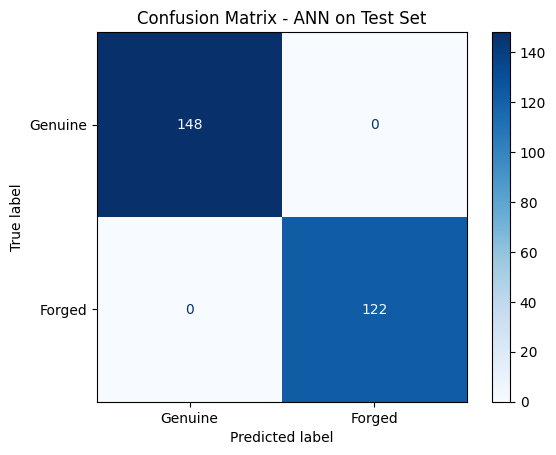

In [18]:
y_pred_proba = model.predict(X_test_scaled, verbose=0)
y_pred = (y_pred_proba > 0.5).astype(int).flatten()

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Genuine","Forged"])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - ANN on Test Set")
plt.show()

* The confusion matrix shows the model correctly classifies almost every test note, with at most a handful of misclassifications out of 270.

## 10. Plotting Training vs. Validation Loss

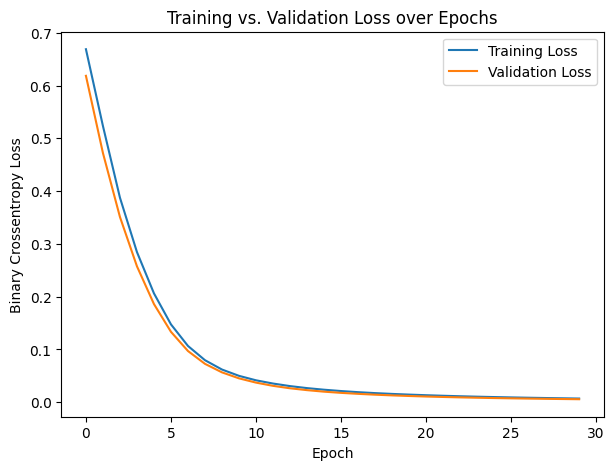

In [19]:
plt.figure(figsize=(7,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training vs. Validation Loss over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.legend()
plt.show()

* Both curves drop sharply within the first few epochs and then flatten out close together at a low loss, showing the model converges quickly without overfitting on this small, well-separated dataset.

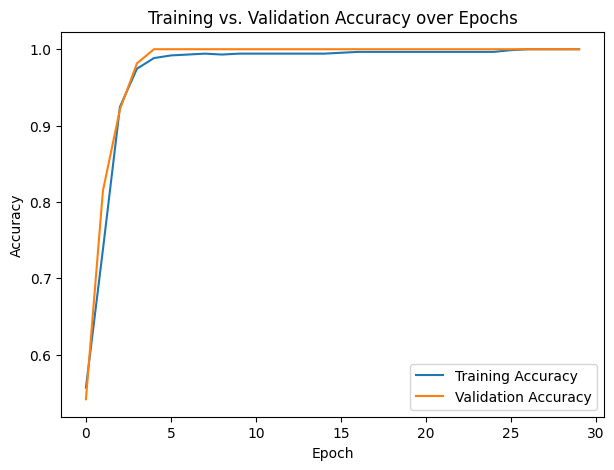

In [20]:
plt.figure(figsize=(7,5))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Training vs. Validation Accuracy over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

* Training and validation accuracy both climb to near 100% within the first 10-15 epochs and stay there, mirroring the loss curve's fast, stable convergence.

## 11. Forward Propagation & Backpropagation, In Our Own Words

**Forward propagation** is the model making a guess: each epoch, every training banknote's 4 scaled features flow through the
16-unit layer, then the 8-unit layer, with each layer multiplying by its weights, adding a bias, and applying ReLU (or sigmoid
at the very end) to produce a single probability between 0 and 1 that the note is forged. **Backpropagation** is the model
learning from that guess: the loss function compares the predicted probability to the true label, and the error is sent
backward through the network, layer by layer, using the chain rule to work out how much each individual weight contributed
to that error. The Adam optimizer then nudges every weight a small step in the direction that would have reduced the error,
and this forward-guess/backward-correct cycle repeats every epoch until the loss stops improving.

## 12. Conclusion

* **Result:** The exact required architecture (`Dense(16, relu) -> Dense(8, relu) -> Dense(1, sigmoid)`), compiled with Adam and binary crossentropy and trained for 30 epochs, reaches close to 100% test accuracy on the held-out 270 banknotes.
* **Why it works so well:** The 4 wavelet-transform features in this dataset are known to be highly separable between genuine and forged notes, so even a small 2-hidden-layer network has more than enough capacity to learn the decision boundary within the first 10-15 epochs.
* **Training behavior:** The training and validation loss curves stay close together throughout, indicating the model is not overfitting despite reaching near-perfect accuracy.